# Word Order Experiments

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import re

import dotenv
import evaluate
import numpy as np
import openai
import pandas as pd
import pyrootutils
import tiktoken
from tokenizers import Tokenizer

PROJECT_ROOT = path = pyrootutils.find_root(indicator=".project-root")
DATA_DIR = PROJECT_ROOT / "data"
BATCHES_DIR = PROJECT_ROOT / "batches"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
FIGURES_DIR = NOTEBOOKS_DIR / "figures"
EXP_DIR = BATCHES_DIR / "word_order"

# create figures directory if it doesn't exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

dotenv.load_dotenv(PROJECT_ROOT / ".env")

True

## Define aesthetics

In [103]:
import aesthetics as aes  # noqa: F401

sns = aes.sns
mtick = aes.mtick
plt = aes.plt

aes.PALETTE_METRICS
aes.PALETTE_MODELS

{'gpt-5-nano': (0.6008331878745565, 0.8439620643509629, 0.5445869552568803),
 'gpt-5-mini': (0.40146167557932255, 0.7547736185383244, 0.3758930481283421),
 'gpt-5': (0.23592156862745095, 0.5521568627450981, 0.3074509803921569),
 'gemini-2.5-flash': (0.4304827007255504,
  0.6778029621634587,
  0.8275565149607244),
 'gemini-2.5-pro': (0.17254901960784308,
  0.4235294117647058,
  0.6033986928104577)}

## Grammars & Samples

<Axes: ylabel='n_words'>

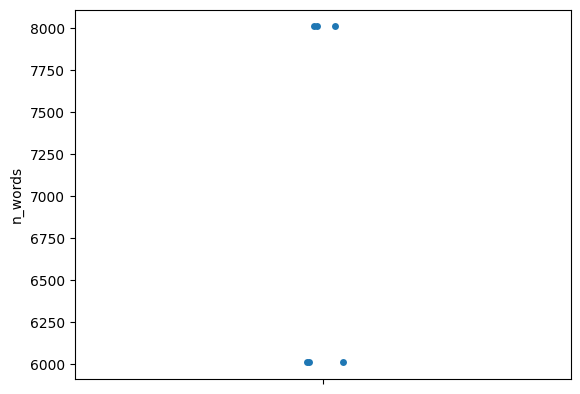

In [4]:
EXPERIMENT_GRAMMARS = DATA_DIR / "wordorder_grammars.txt"

grammar_ids = []
with open(EXPERIMENT_GRAMMARS, "r") as f:
    grammar_ids = [line.strip() for line in f.readlines()]


grammar_files = [f"grammar_{gid}.json" for gid in grammar_ids]
sample_files = [f"samples_{gid}.jsonl" for gid in grammar_ids]

grammars = []
for gf in grammar_files:
    with open(DATA_DIR / gf, "r") as f:
        grammars.append(json.load(f))

samples = []
for path in sample_files:
    with open(DATA_DIR / path, "r") as f:
        samples.extend([json.loads(line) for line in f])
samples_df = pd.DataFrame(samples)
samples_df["input_length"] = samples_df["left_phonetic"].apply(lambda x: len(x.split()))

grammar_sizes = pd.DataFrame(
    [{"name": g["name"], "n_words": g["n_words"]} for g in grammars]
)
sns.stripplot(grammar_sizes["n_words"])

<Axes: xlabel='depth', ylabel='Count'>

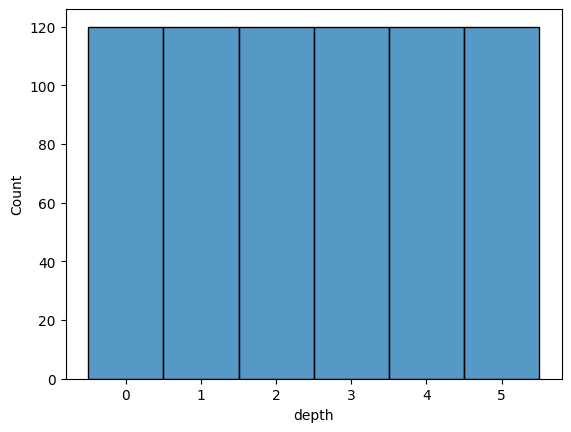

In [5]:
sns.histplot(samples_df["depth"], discrete=True)

## Outputs

In [6]:
openai_client = openai.OpenAI()

tokenizers = {
    "gpt-5-nano": tiktoken.encoding_for_model("gpt-5-nano"),
    "gpt-5-mini": tiktoken.encoding_for_model("gpt-5-mini"),
    "gpt-5": tiktoken.encoding_for_model("gpt-5"),
    "gemini-2.5-flash": Tokenizer.from_pretrained("google/gemma-3-1b-it"),
    "gemini-2.5-pro": Tokenizer.from_pretrained("google/gemma-3-1b-it"),
}


def fuzzy_model(model: str) -> str:
    # strip off the thing that looks like a date
    return re.sub(r"-\d{4}-\d{2}-\d{2}", "", model)

In [33]:
outputs_glob = EXP_DIR.glob("*_output.jsonl")
inputs_glob = EXP_DIR.glob("inputs_*.jsonl")

outputs = []
for path in outputs_glob:
    df = pd.read_json(path, lines=True)
    json_struct = json.loads(df.to_json(orient="records"))
    flat_df = pd.json_normalize(json_struct)

    batch_id = path.name.split("_output.jsonl")[0]

    # extract response
    flat_df["model_response"] = flat_df["response.body.choices"].apply(
        lambda x: x[0]["message"]["content"]
    )

    flat_df["batch_id"] = batch_id
    flat_df["model"] = flat_df["response.body.model"]

    if flat_df["model"].iloc[0].startswith("gpt"):
        flat_df["prompt_tokens"] = flat_df["response.body.usage.prompt_tokens"]
        flat_df["completion_tokens"] = flat_df["response.body.usage.completion_tokens"]
        flat_df["total_tokens"] = flat_df["response.body.usage.total_tokens"]
    elif flat_df["model"].iloc[0].startswith("gemini"):
        flat_df["prompt_tokens"] = flat_df["response.body.usage.promptTokens"]
        flat_df["completion_tokens"] = flat_df["response.body.usage.completionTokens"]
        flat_df["total_tokens"] = flat_df["response.body.usage.totalTokens"]

    if path.name == "batch_68f6e481242c81909cf391cab561e39e_output.jsonl":
        flat_df["input_file"] = "inputs_wordorder_grammars_gpt-5-nano.jsonl"
    elif path.name == "batch_68f6e39d83948190b46dd11feb661ec7_output.jsonl":
        flat_df["input_file"] = "inputs_wordorder_grammars_gpt-5.jsonl"
    else:
        raise ValueError(f"Unknown batch file: {path.name}")

    outputs.append(flat_df)

# gemini_outputs_df = pd.concat(
#     [df for df in outputs if df["model"].iloc[0].startswith("gemini")],
#     ignore_index=True,
# )
# gemini_outputs_df = gemini_outputs_df.drop(
#     [col for col in gemini_outputs_df.columns if col.startswith("response")], axis=1
# )
gpt_outputs_df = pd.concat(
    [df for df in outputs if df["model"].iloc[0].startswith("gpt")],
    ignore_index=True,
)
gpt_outputs_df = gpt_outputs_df.drop(
    [col for col in gpt_outputs_df.columns if col.startswith("response")], axis=1
)

# # For each gpt output, get the input file name from the batch
# batch_ids = gpt_outputs_df["batch_id"].unique()
# for bid in batch_ids:
#     batch = openai_client.batches.retrieve(bid)
#     input_file = openai_client.files.retrieve(batch.input_file_id)
#     gpt_outputs_df.loc[gpt_outputs_df["batch_id"] == bid, "input_file"] = input_file.filename

outputs_df = pd.concat(
    [
        gpt_outputs_df,
        # gemini_outputs_df
    ],
    ignore_index=True,
)

inputs_dfs = []

for f in inputs_glob:
    df = pd.read_json(f, lines=True)
    json_struct = json.loads(df.to_json(orient="records"))
    flat_df = pd.json_normalize(json_struct)
    flat_df["input_file"] = f.name

    if flat_df["body.model"].iloc[0].startswith("gpt"):
        flat_df["grammar_name"] = flat_df["body.metadata.grammar_name"]
        flat_df["input_sentence"] = flat_df["body.metadata.input_sentence"]
        flat_df["output_sentence"] = flat_df["body.metadata.output_sentence"]
        flat_df["depth"] = flat_df["body.metadata.depth"]
        flat_df["n_rules"] = flat_df["body.metadata.n_rules"]
        flat_df["n_words"] = flat_df["body.metadata.n_words"]

    inputs_dfs.append(flat_df)


# gemini_inputs_df = pd.concat(
#     [df for df in inputs_dfs if df["body.model"].iloc[0].startswith("gemini")],
#     ignore_index=True,
# ).drop(["body.max_completion_tokens"], axis=1)
gpt_inputs_df = pd.concat(
    [df for df in inputs_dfs if df["body.model"].iloc[0].startswith("gpt")],
    ignore_index=True,
).drop(["body.max_completion_tokens"], axis=1)

# if the model is a gemini model, it doesn't have metadata. However,
# we are guaranteed that the inputs in the inputs file have `custom_id`s which
# are replicated across input files for gpt models, so we can use that to populate
# the metadata fields

# gemini_inputs_df = pd.merge(
#     gemini_inputs_df,
#     gpt_inputs_df.drop_duplicates(["custom_id"])[
#         [
#             "body.metadata.grammar_name",
#             "body.metadata.input_sentence",
#             "body.metadata.output_sentence",
#             "body.metadata.depth",
#             "body.metadata.n_rules",
#             "body.metadata.n_words",
#             "custom_id",
#         ]
#     ],
#     on="custom_id",
#     how="left",
# ).rename(
#     columns={
#         "body.metadata.grammar_name": "grammar_name",
#         "body.metadata.input_sentence": "input_sentence",
#         "body.metadata.output_sentence": "output_sentence",
#         "body.metadata.depth": "depth",
#         "body.metadata.n_rules": "n_rules",
#         "body.metadata.n_words": "n_words",
#     }
# )

inputs_df = pd.concat(
    [
        gpt_inputs_df,
        # gemini_inputs_df
    ],
    ignore_index=True,
)

merged_df = pd.merge(
    outputs_df,
    inputs_df,
    on=["input_file", "custom_id"],
    how="inner",
)

merged_df = (
    merged_df.drop(
        [col for col in merged_df.columns if col.startswith("response")], axis=1
    )
    .drop(["error"], axis=1)
    .drop([col for col in merged_df.columns if col.startswith("body")], axis=1)
)

merged_df["fuzzy_model"] = merged_df["model"].apply(fuzzy_model)

In [34]:
grammar_blobs = DATA_DIR.glob("grammar_*.json")
grammars = []

for path in grammar_blobs:
    with open(path, "r") as f:
        grammar = json.load(f)
        grammar_name = path.name.split("grammar_")[1].split(".json")[0]
        grammar["grammar_name"] = grammar_name
        grammar = pd.json_normalize(grammar)

        # create lists of vocab words
        grammar["a.words"] = grammar[
            [
                "a.verbs",
                "a.nouns",
                "a.propns",
                "a.prons",
                "a.adjs",
                "a.det_def",
                "a.det_indef",
                "a.comps",
            ]
        ].apply(lambda row: sum(row, []), axis=1)
        grammar["b.words"] = grammar[
            [
                "b.verbs",
                "b.nouns",
                "b.propns",
                "b.prons",
                "b.adjs",
                "b.det_def",
                "b.det_indef",
                "b.comps",
            ]
        ].apply(lambda row: sum(row, []), axis=1)

        # specific to complexity experiment
        grammar["share_head"] = grammar["a.head_initial"] == grammar["b.head_initial"]
        grammar["share_spec"] = grammar["a.spec_initial"] == grammar["b.spec_initial"]

        # merge share_head and share_spec into a single categorical var with four
        # levels: "all same", "head-diff", "spec-diff", "all-diff"
        def categorize(row) -> str:
            if row["share_head"] and row["share_spec"]:
                return "all-same"
            elif row["share_head"] and not row["share_spec"]:
                return "spec-diff"
            elif not row["share_head"] and row["share_spec"]:
                return "head-diff"
            else:
                return "all-diff"

        grammar["word_order_type"] = grammar.apply(categorize, axis=1)

        grammar["syllable_structure"] = grammar["a.syllable_structure"]

        # drop redundant columns
        grammar = grammar.drop(
            columns=[
                "a.head_initial",
                "b.head_initial",
                "a.spec_initial",
                "b.spec_initial",
                "a.pro_drop",
                "b.pro_drop",
                "a.syllable_structure",
                "b.syllable_structure",
            ]
        )

        grammars.append(grammar)

grammars_df = pd.concat(grammars, ignore_index=True)

merged_df = pd.merge(
    merged_df,
    grammars_df[
        [
            "share_head",
            "share_spec",
            "word_order_type",
            "grammar_name",
            "syllable_structure",
            "a.words",
            "b.words",
        ]
    ],
    on="grammar_name",
    # how="outer",
)


merged_df["input_tokens"] = merged_df.apply(
    lambda row: len(
        tokenizers[fuzzy_model(row["model"])].encode(row["input_sentence"])
    ),
    axis=1,
)
merged_df["output_tokens"] = merged_df.apply(
    lambda row: len(
        tokenizers[fuzzy_model(row["model"])].encode(row["output_sentence"])
    ),
    axis=1,
)

### Extract Answer

In [35]:
answer_re = re.compile(
    r"final\s*answer\s*(?::|-|—)?\s*(?:is\s*)?([^\n]+)",
    re.DOTALL | re.IGNORECASE,
)


def extract_answer(model_response):
    matches = answer_re.findall(model_response)
    if matches:
        last_match: str = matches[-1]
        last_match = re.sub(r"[^a-zA-Z\s]", "", last_match)
        last_match = last_match.strip()
        return last_match
    else:
        return None


merged_df = merged_df.drop_duplicates(subset=["custom_id", "batch_id"])
merged_df["model_answer"] = merged_df["model_response"].apply(extract_answer)

In [36]:
# Check how many entries there are where model_answer is null per model
null_answers = merged_df[merged_df["model_answer"].isna()]
null_answers.groupby("fuzzy_model").size()

fuzzy_model
gpt-5-nano    8
dtype: int64

### Compute Metrics

In [37]:
# metrics
def exact_match(row) -> bool:
    if row["model_answer"] is None or row["output_sentence"] is None:
        return False
    return row["model_answer"] == row["output_sentence"]


def bow_match(row) -> bool:
    if row["model_answer"] is None or row["output_sentence"] is None:
        return False
    return sorted(row["model_answer"].split()) == sorted(row["output_sentence"].split())


def edit_similarity(row) -> float:
    if row["model_answer"] is None or row["output_sentence"] is None:
        return 1.0
    from strsimpy.jaro_winkler import JaroWinkler

    jw = JaroWinkler()
    return 1 - jw.distance(row["model_answer"], row["output_sentence"])


def bleu(row) -> float:
    """
    Calculates the BLEU ((bilingual evaluation understudy) score.
    """
    from nltk.translate import bleu as nltk_bleu
    from nltk.translate.bleu_score import SmoothingFunction as SmoothingFunction

    chencherry = SmoothingFunction()

    references: list[list[str]] = [row["output_sentence"].split()]
    hypothesis: list[str] = (
        row["model_answer"].split() if row["model_answer"] is not None else []
    )
    return nltk_bleu(
        references=references,
        hypothesis=hypothesis,
        smoothing_function=chencherry.method7,
    )


def num_oov_words(row) -> int:
    if row["model_answer"] is None or row["output_sentence"] is None:
        return np.nan
    model_words: set[str] = set(row["model_answer"].split())
    output_words: set[str] = set(row["b.words"])
    oov_words: set[str] = model_words - output_words
    return len(oov_words)


# Metrics
merged_df["exact_match"] = merged_df.apply(exact_match, axis=1)
merged_df["bow_match"] = merged_df.apply(bow_match, axis=1)
merged_df["edit_similarity"] = merged_df.apply(edit_similarity, axis=1)
merged_df["num_oov_words"] = merged_df.apply(num_oov_words, axis=1)
merged_df["bleu"] = merged_df.apply(bleu, axis=1)

# manually calculate chrF, chrF++, and BLEU
preds = merged_df["model_answer"].tolist()
refs = merged_df["output_sentence"].tolist()

chrf = evaluate.load("chrf")
chrfScores: list[float] = []
chrfPPScores: list[float] = []
for pred, ref in zip(preds, refs):
    if pred is None:
        pred = ""
    if ref is None:
        ref = ""
    chrfScores.append(
        chrf.compute(
            predictions=[pred],
            references=[[ref]],
            beta=2,
            word_order=0,
        )
    )
    chrfPPScores.append(
        chrf.compute(
            predictions=[pred],
            references=[[ref]],
            beta=2,
            word_order=2,
        )
    )
merged_df["chrF"] = [score["score"] / 100.0 for score in chrfScores]
merged_df["chrF++"] = [score["score"] / 100.0 for score in chrfPPScores]

merged_df["input_words"] = merged_df["input_sentence"].apply(lambda x: len(x.split()))
merged_df["input_words_rounded5"] = merged_df["input_words"].apply(
    lambda x: round(x / 5) * 5
)
merged_df["size"] = merged_df.apply(
    lambda row: int(row["n_rules"]) + int(row["n_words"]),
    axis=1,
)

merged_df["ttc"] = merged_df["completion_tokens"]
merged_df["ttc_binned"] = merged_df["ttc"].apply(
    # log2
    lambda x: round(np.log10(x)) if x > 0 else 0
)

metrics_df = merged_df.melt(
    id_vars=[
        "model",
        "input_words_rounded5",
        "input_words",
        "custom_id",
        "model_answer",
        "output_sentence",
        "depth",
        "size",
        "ttc",
        "ttc_binned",
        "syllable_structure",
        "share_spec",
        "share_head",
        "word_order_type",
        "input_tokens",
        "output_tokens",
    ],
    value_vars=[
        "exact_match",
        "bow_match",
        "edit_similarity",
        "num_oov_words",
        "bleu",
        "chrF",
        "chrF++",
    ],
    var_name="match_type",
    value_name="match_value",
)

# rename `exact_match` and `bow_match` in match_type column
metrics_df["match_type"] = metrics_df["match_type"].replace(
    {
        "exact_match": "Exact Match",
        "bow_match": "Bag of Words",
        "edit_similarity": "Edit Similarity",
        "num_oov_words": "Num OOV Words",
        "bleu": "BLEU Score",
        "chrF++": "chrF++",
        "chrF": "chrF",
    }
)

metrics_df["input_tokens_rounded"] = metrics_df["input_tokens"].apply(
    lambda x: round(x / 5) * 5
)
metrics_df["output_tokens_rounded"] = metrics_df["output_tokens"].apply(
    lambda x: round(x / 5) * 5
)
metrics_df["token_delta"] = abs(
    metrics_df["output_tokens"] - metrics_df["input_tokens"]
)
metrics_df["token_delta_norm"] = abs(
    metrics_df["output_tokens"] - metrics_df["input_tokens"]
) / metrics_df["input_tokens"].replace(0, np.nan)
metrics_df["token_delta_norm_rounded"] = metrics_df["token_delta_norm"].apply(
    lambda x: round(x, 1)
)

# convert the `model` column to an ordered categorical type
metrics_df["model_name"] = metrics_df["model"].apply(lambda x: fuzzy_model(x))
metrics_df["model_name"] = pd.Categorical(
    metrics_df["model_name"],
    categories=[
        "gpt-5-nano",
        "gpt-5-mini",
        "gpt-5",
        "gemini-2.5-flash",
        "gemini-2.5-pro",
    ],
    ordered=True,
)

In [38]:
metrics_df["model_name"].unique()

['gpt-5', 'gpt-5-nano']
Categories (5, object): ['gpt-5-nano' < 'gpt-5-mini' < 'gpt-5' < 'gemini-2.5-flash' < 'gemini-2.5-pro']

## Plots

### Input length distribution

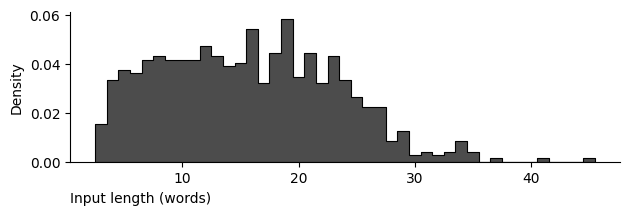

In [86]:
fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))
grid = fig.add_gridspec(1, 1, wspace=0.1)
ax = fig.add_subplot(grid[0, 0])

with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    sns.histplot(
        data=metrics_df,
        x="input_words",
        discrete=True,
        stat="density",
        element="step",
        color="black",
        alpha=0.7,
        ax=ax,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("Input length (words)", loc="left")
    ax.set_ylabel("Density")

plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_input_length_distribution.pdf",
    bbox_inches="tight",
)

### Sentential Complexity

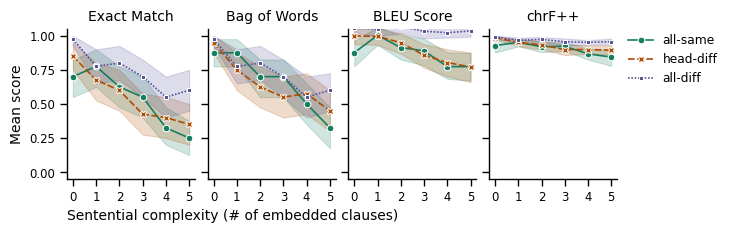

In [104]:
fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))

with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    PERF_METRICS = ["Exact Match", "Bag of Words", "BLEU Score", "chrF++"]
    grid = fig.add_gridspec(1, len(PERF_METRICS), wspace=0.1)

    for i, pm in enumerate(PERF_METRICS):
        ax = fig.add_subplot(grid[0, i])

        sns.lineplot(
            data=metrics_df[(metrics_df["model_name"] == "gpt-5") & (metrics_df["match_type"] == pm)],
            x="depth",
            y="match_value",
            hue="word_order_type",
            style="word_order_type",
            markers=True,
            ax=ax,
            palette=aes.PALETTE_WORDORDER,
            legend=True,
            errorbar="ci",
        )

        ax.set_ylim(-0.05, 1.05)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_title(pm)

        if i == 0:
            ax.set_xlabel("Sentential complexity (# of embedded clauses)", loc="left")
            ax.set_ylabel("Mean score")
            # ax.yaxis.set_major_formatter(aes.PCT_FORMATTER)
        else:
            ax.set_ylabel("")
            ax.yaxis.set_ticklabels([])
            ax.set_xlabel("")

        if i == len(PERF_METRICS) - 1:
            ax.legend(
                title="",
                bbox_to_anchor=(1.05, 1.0),
                loc="upper left",
                borderaxespad=0,
                frameon=False,
            )
        else:
            ax.get_legend().remove()


plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_sentential_complexity_lineplot_ci.pdf",
    bbox_inches="tight",
)

In [105]:
# count number of observations per model and depth
metrics_df[metrics_df["match_type"] == "Exact Match"].groupby(
    ["model_name", "depth"], observed=True
).size().value_counts()

120    12
Name: count, dtype: int64

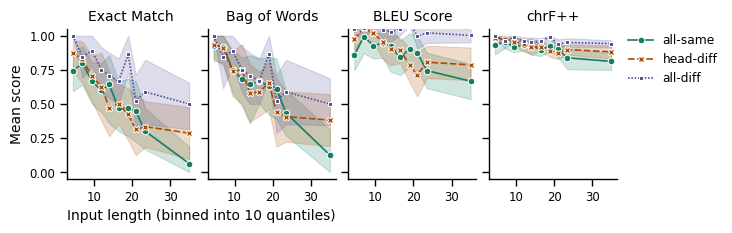

In [106]:
fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))

# Bin input_words into quintiles
N_BINS = 10
metrics_df["input_words_binned_quant"] = pd.qcut(
    metrics_df["input_words"],
    q=N_BINS,
    duplicates="drop",
)
metrics_df["input_words_binned_quant_num"] = metrics_df[
    "input_words_binned_quant"
].apply(lambda x: (x.left + x.right) / 2)

# round to nearest 5
metrics_df["input_words_binned"] = metrics_df["input_words"].apply(
    lambda x: round(x / 10) * 10
)

with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    PERF_METRICS = ["Exact Match", "Bag of Words", "BLEU Score", "chrF++"]
    grid = fig.add_gridspec(1, len(PERF_METRICS), wspace=0.1)

    for i, pm in enumerate(PERF_METRICS):
        ax = fig.add_subplot(grid[0, i])

        sns.lineplot(
            data=metrics_df[(metrics_df["model_name"] == "gpt-5") & (metrics_df["match_type"] == pm)],
            x="input_words_binned_quant_num",
            y="match_value",
            hue="word_order_type",
            style="word_order_type",
            markers=True,
            ax=ax,
            palette=aes.PALETTE_WORDORDER,
            legend=True,
            errorbar="ci",
        )

        ax.set_ylim(-0.05, 1.05)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_title(pm)

        # ax.set_xticks([0, 10, 20, 30, 40])

        if i == 0:
            ax.set_xlabel("Input length (binned into 10 quantiles)", loc="left")
            ax.set_ylabel("Mean score")
            # ax.yaxis.set_major_formatter(aes.PCT_FORMATTER)
        else:
            ax.set_ylabel("")
            ax.yaxis.set_ticklabels([])
            ax.set_xlabel("")

        if i == len(PERF_METRICS) - 1:
            ax.legend(
                title="",
                bbox_to_anchor=(1.05, 1.0),
                loc="upper left",
                borderaxespad=0,
                frameon=False,
            )
        else:
            ax.get_legend().remove()


plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_sentential_complexity_length_lineplot_ci.pdf",
    bbox_inches="tight",
)

In [107]:
# count number of observations per model and depth
metrics_df[metrics_df["match_type"] == "Exact Match"].groupby(
    ["model_name", "input_words_binned_quant_num"], observed=True
).size().value_counts()

88    2
61    2
90    2
65    2
57    2
94    2
67    2
55    2
74    2
69    2
Name: count, dtype: int64

### Grammatical Complexity

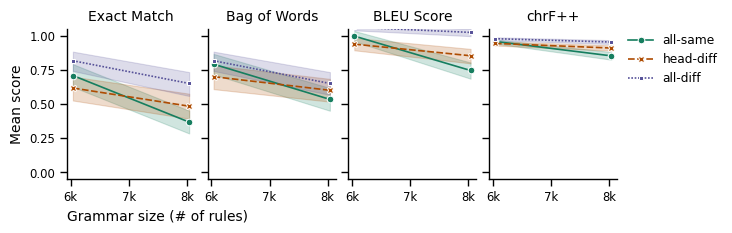

In [93]:
fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))

with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    PERF_METRICS = ["Exact Match", "Bag of Words", "BLEU Score", "chrF++"]
    grid = fig.add_gridspec(1, len(PERF_METRICS), wspace=0.1)

    for i, pm in enumerate(PERF_METRICS):
        ax = fig.add_subplot(grid[0, i])

        sns.lineplot(
            data=metrics_df[(metrics_df["model_name"] == "gpt-5") & (metrics_df["match_type"] == pm)],
            x="size",
            y="match_value",
            hue="word_order_type",
            style="word_order_type",
            markers=True,
            ax=ax,
            palette=aes.PALETTE_WORDORDER,
            legend=True,
            errorbar="ci",
        )

        ax.set_ylim(-0.05, 1.05)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_title(pm)

        # log scale on x-axis?
        # ax.set_xscale("log")
        ax.xaxis.set_major_formatter(aes.NICE_FORMATTER)
        # ax.set_xticks([500, 1000])
        # ax.set_xticklabels([500, 1000])

        if i == 0:
            ax.set_xlabel("Grammar size (# of rules)", loc="left")
            ax.set_ylabel("Mean score")
            # ax.yaxis.set_major_formatter(aes.PCT_FORMATTER)
        else:
            ax.set_ylabel("")
            ax.yaxis.set_ticklabels([])
            ax.set_xlabel("")

        if i == len(PERF_METRICS) - 1:
            ax.legend(
                title="",
                bbox_to_anchor=(1.05, 1.0),
                loc="upper left",
                borderaxespad=0,
                frameon=False,
            )
        else:
            ax.get_legend().remove()


plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_grammatical_complexity_lineplot_ci.pdf",
    bbox_inches="tight",
)

In [94]:
# count number of observations per model and grammar size
metrics_df[metrics_df["match_type"] == "Exact Match"].groupby(
    ["model_name", "size"], observed=True
).size().value_counts()

360    4
Name: count, dtype: int64

### Grammatical & Sentential Complexity

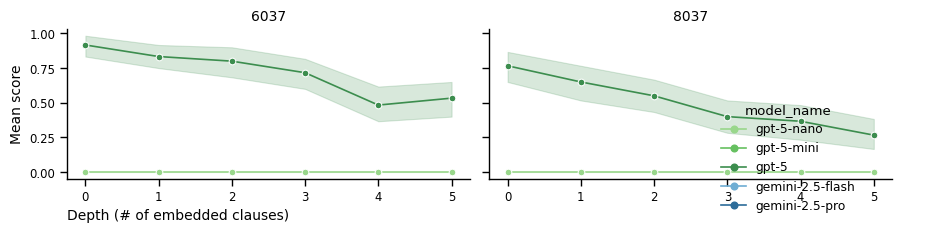

In [95]:
with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    g = sns.relplot(
        data=metrics_df[metrics_df["match_type"].isin(["Exact Match"])],
        x="depth",
        y="match_value",
        hue="model_name",
        # col="match_type",
        col="size",
        kind="line",
        marker="o",
        palette=aes.PALETTE_MODELS,
    )

    g.fig.set_size_inches(aes.PAPER_WIDTH_IN * 1.5, aes.FIG_HEIGHT_SINGLEROW_IN)

    # set titles and labels
    g.set_titles(template="{col_name}")
    g.set_axis_labels("", "Mean score")

    g.axes[0, 0].set_xlabel("Depth (# of embedded clauses)", loc="left")

    # move legend to outside
    g._legend.set_bbox_to_anchor((1.05, 0.5))


plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

### Predicted Translation Length

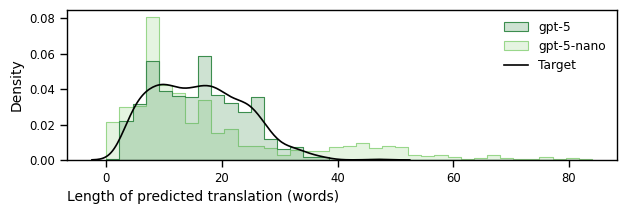

In [96]:
# histogram of "model_answer" lengths by model
merged_df["model_answer_length"] = merged_df["model_answer"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)
merged_df["target_length"] = merged_df["output_sentence"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)

with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))
    grid = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(grid[0, 0])

    sns.histplot(
        data=merged_df,
        x="model_answer_length",
        hue="fuzzy_model",
        element="step",
        stat="density",
        common_norm=False,
        palette=aes.PALETTE_MODELS,
        ax=ax,
    )

    sns.kdeplot(data=merged_df, x="target_length", color="black", ax=ax, label="Target")

    # Histplots are weird about legends. To get a combined legend for
    # both the histplot and the kdeplot, we have to manually merge them.
    old_legend = ax.legend_
    handles = old_legend.legend_handles
    labels = [text.get_text() for text in old_legend.texts]
    plt.legend()
    t_handle, t_label = ax.get_legend_handles_labels()
    handles = handles + t_handle[-1:]
    labels = labels + t_label[-1:]
    ax.legend(handles, labels, frameon=False)
    sns.move_legend(
        ax, "upper right", bbox_to_anchor=(1, 1.0), frameon=False, title=None
    )

    ax.set_xlabel("Length of predicted translation (words)", x=0, ha="left")

plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_predicted_translation_length.pdf",
    bbox_inches="tight",
)

### TTC

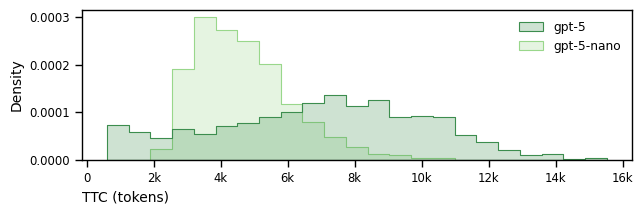

In [97]:
with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
    fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN))
    grid = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(grid[0, 0])

    sns.histplot(
        data=merged_df,
        x="ttc",
        hue="fuzzy_model",
        element="step",
        stat="density",
        common_norm=False,
        palette=aes.PALETTE_MODELS,
        ax=ax,
    )

    ax.xaxis.set_major_formatter(aes.NICE_FORMATTER)

    sns.move_legend(
        ax, "upper right", bbox_to_anchor=(1, 1.0), frameon=False, title=None
    )

    ax.set_xlabel("TTC (tokens)", x=0, ha="left")

plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

plt.savefig(
    FIGURES_DIR / "wordorder_ttc_distribution.pdf",
    bbox_inches="tight",
)